# CHLA-Z uncertainty quantification (full PACE table)

The published CHLA-Z model is a **mean** BRT: one `log10(CHLA)` value per 10 m bin, no interval.

This notebook puts **80% prediction intervals** on that product. Same training table as `notebooks/methods_fit_BRT_CHLA_z.ipynb` (~5,510 rows after biofouling). Features: all `pace_Rrs_*` plus `solar_hour` and `type`.

1. **Mean BRT** — current product (baseline; no UQ)
2. **Quantile BRT** — 10th / 50th / 90th percentiles (`loss="quantile"`); width varies, often undercovers
3. **Mean BRT + conformal** — constant-width interval per depth, calibrated to ~80% coverage
4. **CQR** — conformalized quantile regression (Romano et al. 2019): q10/q90 fit on the **fit** split only, then a conformal pad from calib so coverage hits ~80% while width still varies
5. **CQR Mondrian** — same, with a separate pad for Argo vs OOI

A later cell adds a **5% spectrally correlated Rrs gain** Monte Carlo through the mean BRT. That is input sensitivity, not a replacement for CQR (CQR already includes typical matchup Rrs error; do not add the two widths).

Split is by **float / instrument**, not by row: Argo `PLATFORM_NUMBER`, OOI instrument id (`profile_id` without the trailing date). Argo and OOI groups are split separately (80/20, `random_state=42`) so both sources stay in train and test. Then 20% of **train groups** are conformal calib. Missing CHLA is dropped **per bin**. Cutoffs use the finite-sample conformal quantile, not `np.quantile(..., 0.80)`.

A final section refits **CQR only** on the **OLCI–PACE overlap** (all 11 OLCI bands finite; same ids as `olci_l3_brt_compare.ipynb`) with PACE-full vs OLCI-11 features.

Success is **not** a lower RMSE. Success is coverage near 80% **and** width that changes with depth / CHLA. A grouped split is allowed to cover *worse* than a random row split — that is the more honest number.

Data: local `chla-z/brt_training_data/*.parquet` and `olci_l3_matchups.parquet`. Kernel: `gobgc`. Does not import `ml_utils`.


## Imports and paths


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

BRT_KW = dict(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    validation_fraction=0.1,
    early_stopping=True,
    random_state=42,
)
EXTRA = ["solar_hour", "type"]

DATA = Path("/Users/nmamnun/GO-BGC-Workshop/chla-z/brt_training_data")
HERE = Path("/Users/nmamnun/GO-BGC-Workshop/2026-go-bgc-hackweek/contributor_folders/nama")
if not (DATA / "CHLA_argo_profiles_plus_PACE.parquet").is_file():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        cand = p.parent / "chla-z" / "brt_training_data"
        if (cand / "CHLA_argo_profiles_plus_PACE.parquet").is_file():
            DATA = cand
            break
        if (p / "contributor_folders" / "nama").is_dir():
            HERE = p / "contributor_folders" / "nama"

OLCI_BANDS = [400, 412, 443, 490, 510, 560, 620, 665, 674, 681, 709]
OLCI_COLS = [f"olci_Rrs_{nm}" for nm in OLCI_BANDS]
OLCI_FILE = HERE / "olci_l3_matchups.parquet"

def add_solar_hour(df, time="time", lon="lon"):
    """Local solar hour ≈ UTC hour + lon/15 (same formula as ml_utils)."""
    out = df.copy()
    t = pd.to_datetime(out[time], utc=True)
    utc_hour = t.dt.hour + t.dt.minute / 60.0 + t.dt.second / 3600.0
    lon_e = out[lon].astype(float)
    if np.nanmax(lon_e.to_numpy()) > 180:
        lon_e = ((lon_e + 180) % 360) - 180
    out["solar_hour"] = (utc_hour.to_numpy() + lon_e.to_numpy() / 15.0) % 24.0
    return out

print("DATA:", DATA)
print("OLCI:", OLCI_FILE, "exists", OLCI_FILE.is_file())
print("parquet files:", sorted(p.name for p in DATA.glob("*.parquet")))


DATA: /Users/nmamnun/GO-BGC-Workshop/chla-z/brt_training_data
OLCI: /Users/nmamnun/GO-BGC-Workshop/2026-go-bgc-hackweek/contributor_folders/nama/olci_l3_matchups.parquet exists True
parquet files: ['CHLA_argo_profiles_plus_PACE.parquet', 'CHLA_ooi_profiles_plus_PACE.parquet']


## Load Argo + OOI matchups

Same merge as the methods notebook. Keep every row (including duplicate OOI `profile_id`s) so this is UQ on the **published table**. Add a **group id**: Argo float (`PLATFORM_NUMBER`) or OOI instrument (prefix of `profile_id`). The OLCI overlap is a later filter, not this table.


In [2]:
argo = pd.read_parquet(DATA / "CHLA_argo_profiles_plus_PACE.parquet")
argo = argo.rename(columns={"LATITUDE": "lat", "LONGITUDE": "lon", "TIME": "time"})

rrs_cols = [c for c in argo.columns if c.startswith("pace_Rrs_") and c[-1].isdigit()]
chl_cols = [c for c in argo.columns if c.startswith("CHLA_") and c[-1].isdigit()]
cols = ["profile_id", "time", "lat", "lon"] + rrs_cols + chl_cols + ["pace_chlor_a", "pace_Kd_490"]
argo_groups = "argo-" + argo["PLATFORM_NUMBER"].astype(str)
argo = argo[cols]
argo["type"] = 0
argo["group_id"] = argo_groups

ooi = pd.read_parquet(DATA / "CHLA_ooi_profiles_plus_PACE.parquet")
ooi_groups = ooi["profile_id"].astype(str).str.replace(r"_\d{8}$", "", regex=True)
ooi = ooi[cols]
ooi["type"] = 1
ooi["group_id"] = ooi_groups

dataset = pd.concat([argo, ooi], ignore_index=True)
dataset = add_solar_hour(dataset)

rrs_cols = [c for c in dataset.columns if c.startswith("pace_Rrs_") and c[-1].isdigit()]
dataset = dataset.dropna(subset=rrs_cols, how="all").reset_index(drop=True)
print("after merge + Rrs dropna:", dataset.shape)
print(
    "groups:",
    dataset["group_id"].nunique(),
    "Argo floats:",
    dataset.loc[dataset["type"] == 0, "group_id"].nunique(),
    "OOI instruments:",
    dataset.loc[dataset["type"] == 1, "group_id"].nunique(),
)


after merge + Rrs dropna: (5540, 201)
groups: 424 Argo floats: 394 OOI instruments: 30


## Drop likely biofouled deep profiles


In [3]:
def parse_depth_bin(col):
    _, a, b = col.split("_")
    return int(a), int(b)

chl_cols = [c for c in dataset.columns if c.startswith("CHLA_") and c[-1].isdigit()]
chl_cols = sorted(chl_cols, key=lambda c: parse_depth_bin(c)[0])

deep100_200_bins = []
for c in chl_cols:
    a, b = parse_depth_bin(c)
    z_center = 0.5 * (a + b)
    if 100 <= z_center <= 200:
        deep100_200_bins.append(c)

def flag_deep_biofouling(df, deep_bins, min_valid=5, min_chl=1.0, max_spread=2):
    bad = []
    for pid, sub in df.groupby("profile_id"):
        vals = sub[deep_bins].to_numpy(dtype=float).ravel()
        vals = vals[np.isfinite(vals)]
        if vals.size < min_valid:
            continue
        if (vals.min() > min_chl) and ((vals.max() - vals.min()) < max_spread):
            bad.append(pid)
    return bad

bad_ids = flag_deep_biofouling(dataset, deep100_200_bins)
print(f"Flagged {len(bad_ids)} suspect profiles.")
dataset = dataset[~dataset["profile_id"].isin(bad_ids)].reset_index(drop=True)
print("clean dataset:", dataset.shape)
print("depth bins:", len(chl_cols), chl_cols[0], "...", chl_cols[-1])

Flagged 20 suspect profiles.
clean dataset: (5510, 201)
depth bins: 20 CHLA_0_10 ... CHLA_190_200


## Shared train / test / conformal-calib split

**Group** split (`random_state=42`), not the methods notebook's row split. A float (Argo) or instrument (OOI) is only in train or only in test. Argo and OOI groups are drawn separately so both sources appear in every split. Then 20% of **train groups** are held out to set conformal width. Test groups are never used for that.


In [4]:
feats = rrs_cols + [c for c in EXTRA if c in dataset.columns]


def split_by_group(df, test_size=0.2, random_state=42):
    """80/20 unique group_id within each type; returns iloc positions into df."""
    is_test = np.zeros(len(df), dtype=bool)
    groups = df["group_id"].to_numpy()
    types = df["type"].to_numpy()
    for typ in np.unique(types):
        g = np.unique(groups[types == typ])
        if len(g) < 2:
            continue
        _, g_te = train_test_split(g, test_size=test_size, random_state=random_state)
        is_test |= (types == typ) & np.isin(groups, g_te)
    idx = np.arange(len(df))
    return idx[~is_test], idx[is_test]


train_idx, test_idx = split_by_group(dataset, test_size=0.2, random_state=42)
fit_rel, cal_rel = split_by_group(dataset.iloc[train_idx].reset_index(drop=True), test_size=0.2, random_state=42)
fit_idx = train_idx[fit_rel]
cal_idx = train_idx[cal_rel]

tr_g = set(dataset.iloc[train_idx]["group_id"])
te_g = set(dataset.iloc[test_idx]["group_id"])
fi_g = set(dataset.iloc[fit_idx]["group_id"])
ca_g = set(dataset.iloc[cal_idx]["group_id"])
assert tr_g.isdisjoint(te_g)
assert fi_g.isdisjoint(ca_g)
assert ca_g.isdisjoint(te_g)

print(f"features: {len(feats)}  rows={len(dataset)}")
print(
    f"train={len(train_idx)} ({len(tr_g)} groups)  "
    f"fit={len(fit_idx)} ({len(fi_g)} groups)  "
    f"calib={len(cal_idx)} ({len(ca_g)} groups)  "
    f"test={len(test_idx)} ({len(te_g)} groups)"
)
print(
    "test Argo groups:",
    dataset.iloc[test_idx].loc[dataset.iloc[test_idx]["type"] == 0, "group_id"].nunique(),
    "test OOI groups:",
    dataset.iloc[test_idx].loc[dataset.iloc[test_idx]["type"] == 1, "group_id"].nunique(),
)


def bin_xy(df, idx, y_col, feat_cols=None):
    """log10(CHLA) for one bin on a row-index subset; drop non-positive / missing y."""
    feat_cols = feats if feat_cols is None else feat_cols
    tab = df.iloc[idx][["profile_id", y_col] + feat_cols].copy()
    tab = tab.rename(columns={y_col: "y"})
    tab = tab.where(tab["y"] > 0)
    tab["y"] = np.log10(tab["y"])
    tab = tab.dropna(subset=["y"])
    return tab, tab[feat_cols], tab["y"]


def fit_mean(X, y):
    return HistGradientBoostingRegressor(**BRT_KW).fit(X, y)


def fit_quantile(q, X, y):
    return HistGradientBoostingRegressor(loss="quantile", quantile=q, **BRT_KW).fit(X, y)


def order_quantiles(lo, md, hi):
    """Enforce lo <= md <= hi (separate quantile models can cross)."""
    stacked = np.sort(np.vstack([np.asarray(lo), np.asarray(md), np.asarray(hi)]), axis=0)
    return stacked[0], stacked[1], stacked[2]


def coverage_and_width(y_true, lo, hi):
    y_true = np.asarray(y_true)
    lo, hi = np.asarray(lo), np.asarray(hi)
    inside = (y_true >= lo) & (y_true <= hi)
    return float(np.mean(inside)), float(np.mean(hi - lo))


ALPHA = 0.20  # 80% intervals


def conformal_cutoff(scores, alpha=ALPHA):
    """Finite-sample split-conformal quantile (1-indexed k = ceil((n+1)(1-alpha)))."""
    s = np.sort(np.asarray(scores, dtype=float).ravel())
    n = s.size
    if n == 0:
        return np.nan
    k = int(np.ceil((n + 1) * (1.0 - alpha)))
    if k > n:
        return float(s[-1])
    return float(s[k - 1])


def cqr_scores(y, lo, hi):
    y = np.asarray(y, dtype=float).ravel()
    lo = np.asarray(lo, dtype=float).ravel()
    hi = np.asarray(hi, dtype=float).ravel()
    return np.maximum(lo - y, y - hi)


def q_interval(model_lo, model_hi, X):
    lo = model_lo.predict(X)
    hi = model_hi.predict(X)
    return np.minimum(lo, hi), np.maximum(lo, hi)


def mondrian_ehat(scores, groups, alpha=ALPHA, min_n=30):
    """Per-group conformal pad; fall back to pooled if a group is small."""
    scores = np.asarray(scores, dtype=float).ravel()
    groups = np.asarray(groups)
    pooled = conformal_cutoff(scores, alpha)
    ehat = {}
    for g in np.unique(groups):
        m = groups == g
        ehat[int(g)] = conformal_cutoff(scores[m], alpha) if int(m.sum()) >= min_n else pooled
    return ehat, pooled


def eval_point(name, y_true, y_hat):
    return {
        "model": name,
        "n_test": int(len(y_true)),
        "rmse_log": float(np.sqrt(mean_squared_error(y_true, y_hat))),
        "r2_log": float(r2_score(y_true, y_hat)),
        "rmse_lin": float(np.sqrt(mean_squared_error(10 ** np.asarray(y_true), 10 ** np.asarray(y_hat)))),
    }


features: 174  rows=5510
train=4235 (339 groups)  fit=3271 (271 groups)  calib=964 (68 groups)  test=1275 (85 groups)
test Argo groups: 79 test OOI groups: 6


## Surface (`CHLA_0_10`)

Fit baselines and CQR on the surface bin.

- **Quantile** models use the full train split (product-style).
- **Conformal** mean and **CQR** q10/q90 use the **fit** split only; pads come from calib with the finite-sample conformal quantile.
- **CQR Mondrian** uses the same q10/q90, with a separate pad for Argo vs OOI.


In [5]:
Y_COL = "CHLA_0_10"

_, X_train, y_train = bin_xy(dataset, train_idx, Y_COL)
_, X_fit, y_fit = bin_xy(dataset, fit_idx, Y_COL)
_, X_cal, y_cal = bin_xy(dataset, cal_idx, Y_COL)
tab_test, X_test, y_test = bin_xy(dataset, test_idx, Y_COL)

print(f"surface train={len(X_train)}  fit={len(X_fit)}  calib={len(X_cal)}  test={len(X_test)}")

mean_brt = fit_mean(X_train, y_train)
q10 = fit_quantile(0.10, X_train, y_train)
q50 = fit_quantile(0.50, X_train, y_train)
q90 = fit_quantile(0.90, X_train, y_train)

mean_for_conf = fit_mean(X_fit, y_fit)
s_hat = conformal_cutoff(np.abs(y_cal.to_numpy() - mean_for_conf.predict(X_cal)))
print(f"conformal 80% half-width (log10 CHLA): {s_hat:.3f}  (~factor {10 ** s_hat:.2f}x on linear CHLA)")

q10_cqr = fit_quantile(0.10, X_fit, y_fit)
q90_cqr = fit_quantile(0.90, X_fit, y_fit)
lo_cal_q, hi_cal_q = q_interval(q10_cqr, q90_cqr, X_cal)
scores_cal = cqr_scores(y_cal, lo_cal_q, hi_cal_q)
e_cqr = conformal_cutoff(scores_cal)
groups_cal = X_cal["type"].fillna(-1).astype(int).to_numpy()
e_by_type, _ = mondrian_ehat(scores_cal, groups_cal)
print(f"CQR pad (log10 CHLA): {e_cqr:.3f}")
print("Mondrian CQR pad by type (0=Argo, 1=OOI):", e_by_type)

surface train=2675  fit=2043  calib=632  test=1028
conformal 80% half-width (log10 CHLA): 0.337  (~factor 2.17x on linear CHLA)
CQR pad (log10 CHLA): 0.017
Mondrian CQR pad by type (0=Argo, 1=OOI): {0: 0.12745120743694693, 1: -0.05997371108842481}


In [6]:
y_mean = mean_brt.predict(X_test)
y_p10 = q10.predict(X_test)
y_p50 = q50.predict(X_test)
y_p90 = q90.predict(X_test)
y_p10, y_p50, y_p90 = order_quantiles(y_p10, y_p50, y_p90)

y_conf = mean_for_conf.predict(X_test)
lo_conf, hi_conf = y_conf - s_hat, y_conf + s_hat

cov_q, wid_q = coverage_and_width(y_test, y_p10, y_p90)
cov_c, wid_c = coverage_and_width(y_test, lo_conf, hi_conf)

lo_cqr0, hi_cqr0 = q_interval(q10_cqr, q90_cqr, X_test)
lo_cqr, hi_cqr = lo_cqr0 - e_cqr, hi_cqr0 + e_cqr
cov_cqr, wid_cqr = coverage_and_width(y_test, lo_cqr, hi_cqr)

g_te = X_test["type"].fillna(-1).astype(int).to_numpy()
e_te = np.array([e_by_type.get(int(g), e_cqr) for g in g_te])
lo_m, hi_m = lo_cqr0 - e_te, hi_cqr0 + e_te
cov_m, wid_m = coverage_and_width(y_test, lo_m, hi_m)

metrics = pd.DataFrame([
    {**eval_point("mean BRT (no UQ)", y_test, y_mean),
     "coverage_80": np.nan, "mean_width_log": np.nan},
    {**eval_point("quantile BRT (median)", y_test, y_p50),
     "coverage_80": cov_q, "mean_width_log": wid_q},
    {**eval_point("mean BRT + conformal", y_test, y_conf),
     "coverage_80": cov_c, "mean_width_log": wid_c},
    {**eval_point("CQR", y_test, y_p50),
     "coverage_80": cov_cqr, "mean_width_log": wid_cqr},
    {**eval_point("CQR Mondrian", y_test, y_p50),
     "coverage_80": cov_m, "mean_width_log": wid_m},
])
metrics

,model,n_test,rmse_log,r2_log,rmse_lin,coverage_80,mean_width_log
0,mean BRT (no UQ),1028,0.345108,0.689439,0.855160,NaN,NaN
1,quantile BRT (median),1028,0.342814,0.693555,0.854685,0.563230,0.568947
2,mean BRT + conformal,1028,0.341269,0.696310,0.861418,0.718872,0.674422
3,CQR,1028,0.342814,0.693555,0.854685,0.680934,0.719223
4,CQR Mondrian,1028,0.342814,0.693555,0.854685,0.683852,0.723003


### Surface plots

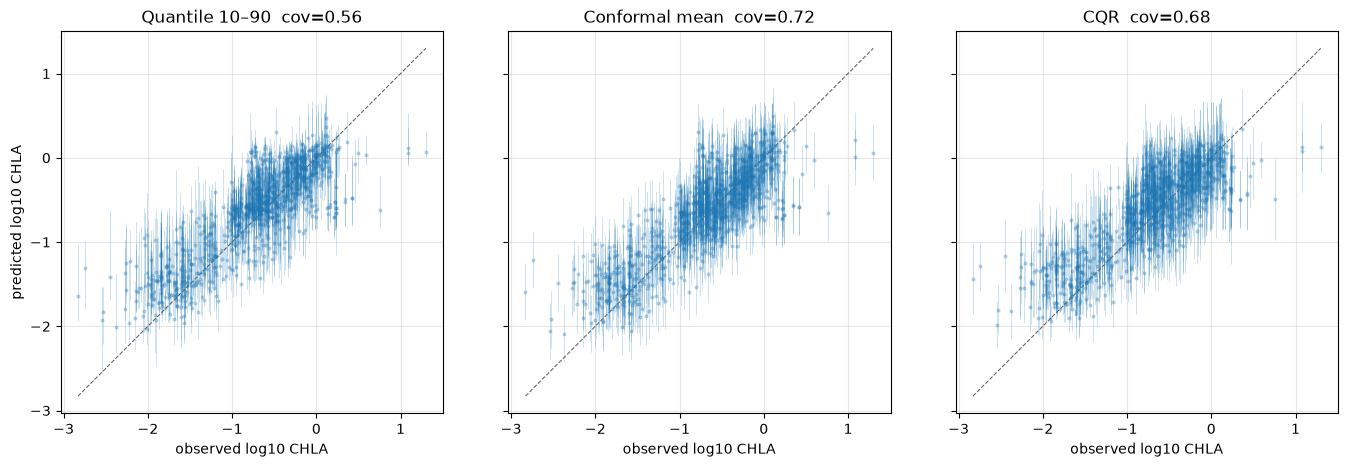

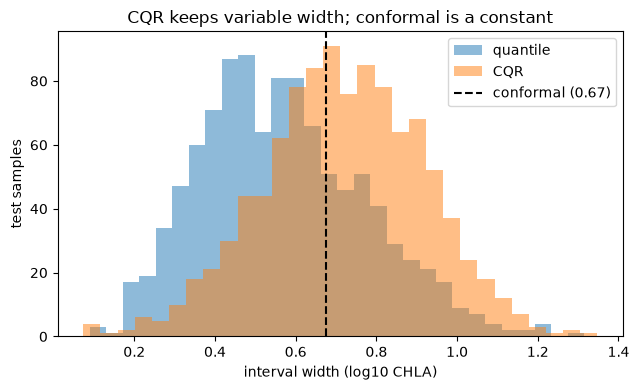

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True, sharey=True)
lims = [
    min(y_test.min(), y_p10.min(), lo_conf.min(), lo_cqr.min()),
    max(y_test.max(), y_p90.max(), hi_conf.max(), hi_cqr.max()),
]
mid_cqr = 0.5 * (lo_cqr + hi_cqr)

panels = [
    (y_p50, y_p50 - y_p10, y_p90 - y_p50, f"Quantile 10–90  cov={cov_q:.2f}"),
    (y_conf, np.full(len(y_test), s_hat), np.full(len(y_test), s_hat),
     f"Conformal mean  cov={cov_c:.2f}"),
    (mid_cqr, mid_cqr - lo_cqr, hi_cqr - mid_cqr, f"CQR  cov={cov_cqr:.2f}"),
]
for ax, (yhat, lo_err, hi_err, title) in zip(axes, panels):
    ax.plot(lims, lims, "k--", lw=0.8, alpha=0.6)
    ax.errorbar(
        y_test, yhat, yerr=[np.maximum(lo_err, 0), np.maximum(hi_err, 0)],
        fmt="o", ms=2, alpha=0.25, elinewidth=0.6,
    )
    ax.set_title(title)
    ax.set_xlabel("observed log10 CHLA")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("predicted log10 CHLA")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(y_p90 - y_p10, bins=30, alpha=0.5, label="quantile")
ax.hist(hi_cqr - lo_cqr, bins=30, alpha=0.5, label="CQR")
ax.axvline(2 * s_hat, color="k", ls="--", label=f"conformal ({2 * s_hat:.2f})")
ax.set_xlabel("interval width (log10 CHLA)")
ax.set_ylabel("test samples")
ax.legend()
ax.set_title("CQR keeps variable width; conformal is a constant")
plt.tight_layout()
plt.show()

## Surface coverage by Argo vs OOI


In [8]:
slice_rows = []
yt = y_test.to_numpy()
for src, mask in [("Argo", tab_test["type"] == 0), ("OOI", tab_test["type"] == 1)]:
    m = mask.to_numpy()
    if m.sum() == 0:
        continue
    cov_qs, wid_qs = coverage_and_width(yt[m], y_p10[m], y_p90[m])
    cov_cs, wid_cs = coverage_and_width(yt[m], lo_conf[m], hi_conf[m])
    cov_cq, wid_cq = coverage_and_width(yt[m], lo_cqr[m], hi_cqr[m])
    cov_md, wid_md = coverage_and_width(yt[m], lo_m[m], hi_m[m])
    slice_rows.append({
        "source": src,
        "n_test": int(m.sum()),
        "quantile_cov": cov_qs,
        "conformal_cov": cov_cs,
        "cqr_cov": cov_cq,
        "mondrian_cov": cov_md,
        "quantile_width": wid_qs,
        "conformal_width": wid_cs,
        "cqr_width": wid_cq,
        "mondrian_width": wid_md,
    })
pd.DataFrame(slice_rows)

,source,n_test,quantile_cov,conformal_cov,cqr_cov,mondrian_cov,quantile_width,conformal_width,cqr_width,mondrian_width
0,Argo,432,0.543981,0.613426,0.576389,0.738426,0.695413,0.674422,0.708145,0.929251
1,OOI,596,0.577181,0.795302,0.756711,0.644295,0.477281,0.674422,0.727252,0.573508


## All 20 depth bins

Same `train_idx` / `test_idx` / `fit_idx` / `cal_idx` for every bin.

- Raw quantile: full train (baseline; often undercovers).
- Constant conformal: mean on fit, pad from calib (finite-sample).
- CQR: q10/q90 on fit, one pad from calib (variable width + calibrated coverage).

Keep the **mean BRT** and **CQR** models per bin (`mean_models`, `cqr_pack`) for the Rrs Monte Carlo below.


In [9]:
depth_rows = []
saved_diag = {}
mean_models = {}
cqr_pack = {}

for y_col in chl_cols:
    _, Xtr, ytr = bin_xy(dataset, train_idx, y_col)
    _, Xfi, yfi = bin_xy(dataset, fit_idx, y_col)
    _, Xca, yca = bin_xy(dataset, cal_idx, y_col)
    tab_te, Xte, yte = bin_xy(dataset, test_idx, y_col)

    z0, z1 = parse_depth_bin(y_col)
    zc = 0.5 * (z0 + z1)
    if len(yte) < 20 or len(ytr) < 50 or len(yca) < 20:
        print(f"skip {y_col}: n_train={len(ytr)} n_cal={len(yca)} n_test={len(yte)}")
        continue

    m_mean = fit_mean(Xtr, ytr)
    m10 = fit_quantile(0.10, Xtr, ytr)
    m50 = fit_quantile(0.50, Xtr, ytr)
    m90 = fit_quantile(0.90, Xtr, ytr)
    m_conf = fit_mean(Xfi, yfi)
    s = conformal_cutoff(np.abs(yca.to_numpy() - m_conf.predict(Xca)))

    q10_c = fit_quantile(0.10, Xfi, yfi)
    q90_c = fit_quantile(0.90, Xfi, yfi)
    lo_ca, hi_ca = q_interval(q10_c, q90_c, Xca)
    sc_ca = cqr_scores(yca, lo_ca, hi_ca)
    e_pad = conformal_cutoff(sc_ca)
    g_ca = Xca["type"].fillna(-1).astype(int).to_numpy()
    e_grp, _ = mondrian_ehat(sc_ca, g_ca)

    yhat_mean = m_mean.predict(Xte)
    lo_q = m10.predict(Xte)
    md_q = m50.predict(Xte)
    hi_q = m90.predict(Xte)
    lo_q, md_q, hi_q = order_quantiles(lo_q, md_q, hi_q)
    yhat_c = m_conf.predict(Xte)
    lo_cq0, hi_cq0 = q_interval(q10_c, q90_c, Xte)
    lo_cq, hi_cq = lo_cq0 - e_pad, hi_cq0 + e_pad
    g_te = Xte["type"].fillna(-1).astype(int).to_numpy()
    e_row = np.array([e_grp.get(int(g), e_pad) for g in g_te])
    lo_md, hi_md = lo_cq0 - e_row, hi_cq0 + e_row

    cov_q_z, wid_q_z = coverage_and_width(yte, lo_q, hi_q)
    cov_c_z, wid_c_z = coverage_and_width(yte, yhat_c - s, yhat_c + s)
    cov_cq_z, wid_cq_z = coverage_and_width(yte, lo_cq, hi_cq)
    cov_md_z, wid_md_z = coverage_and_width(yte, lo_md, hi_md)

    row = {
        "bin": y_col,
        "z_center_m": zc,
        "n_train": len(ytr),
        "n_test": len(yte),
        "rmse_mean": float(np.sqrt(mean_squared_error(yte, yhat_mean))),
        "rmse_q50": float(np.sqrt(mean_squared_error(yte, md_q))),
        "quantile_coverage_80": cov_q_z,
        "quantile_width_log": wid_q_z,
        "conformal_coverage_80": cov_c_z,
        "conformal_width_log": wid_c_z,
        "conformal_halfwidth_log": s,
        "cqr_coverage_80": cov_cq_z,
        "cqr_width_log": wid_cq_z,
        "cqr_pad_log": e_pad,
        "mondrian_coverage_80": cov_md_z,
        "mondrian_width_log": wid_md_z,
    }
    depth_rows.append(row)
    mean_models[y_col] = m_mean
    cqr_pack[y_col] = {"q10": q10_c, "q90": q90_c, "e_pad": e_pad}
    if y_col in ("CHLA_0_10", "CHLA_150_160"):
        saved_diag[y_col] = {
            "y": np.asarray(yte),
            "pred": np.asarray(yhat_mean),
            "lo_q": lo_q, "hi_q": hi_q,
            "lo_c": yhat_c - s, "hi_c": yhat_c + s,
            "lo_cqr": lo_cq, "hi_cqr": hi_cq,
            "lo_m": lo_md, "hi_m": hi_md,
        }
    print(
        f"{y_col:16} n_test={len(yte):4d}  "
        f"cov_q={cov_q_z:.2f}  cov_c={cov_c_z:.2f}  cov_cqr={cov_cq_z:.2f}  "
        f"wid_q={wid_q_z:.2f}  wid_c={wid_c_z:.2f}  wid_cqr={wid_cq_z:.2f}"
    )

by_depth = pd.DataFrame(depth_rows)
by_depth

CHLA_0_10        n_test=1028  cov_q=0.56  cov_c=0.72  cov_cqr=0.68  wid_q=0.57  wid_c=0.67  wid_cqr=0.72
CHLA_10_20       n_test= 456  cov_q=0.58  cov_c=0.80  cov_cqr=0.77  wid_q=0.61  wid_c=0.79  wid_cqr=0.80
CHLA_20_30       n_test= 496  cov_q=0.74  cov_c=0.88  cov_cqr=0.87  wid_q=0.63  wid_c=0.73  wid_cqr=0.80
CHLA_30_40       n_test= 526  cov_q=0.70  cov_c=0.89  cov_cqr=0.91  wid_q=0.60  wid_c=0.76  wid_cqr=0.85
CHLA_40_50       n_test= 528  cov_q=0.73  cov_c=0.89  cov_cqr=0.91  wid_q=0.59  wid_c=0.81  wid_cqr=0.86
CHLA_50_60       n_test= 515  cov_q=0.78  cov_c=0.90  cov_cqr=0.94  wid_q=0.65  wid_c=0.90  wid_cqr=0.98
CHLA_60_70       n_test= 521  cov_q=0.75  cov_c=0.92  cov_cqr=0.92  wid_q=0.64  wid_c=0.96  wid_cqr=0.94
CHLA_70_80       n_test= 527  cov_q=0.75  cov_c=0.93  cov_cqr=0.94  wid_q=0.63  wid_c=1.02  wid_cqr=1.02
CHLA_80_90       n_test= 522  cov_q=0.80  cov_c=0.84  cov_cqr=0.81  wid_q=0.70  wid_c=0.77  wid_cqr=0.77
CHLA_90_100      n_test= 522  cov_q=0.79  cov_c=0.82  c

,bin,z_center_m,n_train,n_test,rmse_mean,rmse_q50,quantile_coverage_80,quantile_width_log,conformal_coverage_80,conformal_width_log,conformal_halfwidth_log,cqr_coverage_80,cqr_width_log,cqr_pad_log,mondrian_coverage_80,mondrian_width_log
0,CHLA_0_10,5.0,2675,1028,0.345108,0.342814,0.563230,0.568947,0.718872,0.674422,0.337211,0.680934,0.719223,0.016898,0.683852,0.723003
1,CHLA_10_20,15.0,1763,456,0.317136,0.322186,0.583333,0.609194,0.800439,0.785147,0.392573,0.769737,0.800870,0.123098,0.774123,0.824194
2,CHLA_20_30,25.0,2347,496,0.246658,0.257489,0.735887,0.628038,0.879032,0.727694,0.363847,0.866935,0.799924,0.100929,0.858871,0.807167
3,CHLA_30_40,35.0,2560,526,0.232376,0.235369,0.701521,0.600501,0.887833,0.755844,0.377922,0.906844,0.850706,0.117590,0.876426,0.812685
4,CHLA_40_50,45.0,2521,528,0.260922,0.260865,0.732955,0.593906,0.893939,0.810901,0.405451,0.909091,0.859149,0.117121,0.899621,0.871267
5,CHLA_50_60,55.0,2490,515,0.263635,0.257205,0.778641,0.647677,0.902913,0.902460,0.451230,0.937864,0.982392,0.179810,0.926214,0.949794
6,CHLA_60_70,65.0,2510,521,0.285383,0.283037,0.750480,0.642096,0.921305,0.959480,0.479740,0.921305,0.944475,0.154523,0.915547,0.986132
7,CHLA_70_80,75.0,2475,527,0.269671,0.273714,0.749526,0.627811,0.933586,1.023407,0.511704,0.941176,1.017447,0.163846,0.907021,1.032606
8,CHLA_80_90,85.0,1927,522,0.311219,0.301522,0.798851,0.698287,0.837165,0.768787,0.384393,0.812261,0.765892,0.027482,0.812261,0.765892
9,CHLA_90_100,95.0,1859,522,0.327148,0.330103,0.791188,0.694656,0.821839,0.760651,0.380325,0.875479,0.849376,0.106890,0.875479,0.849376


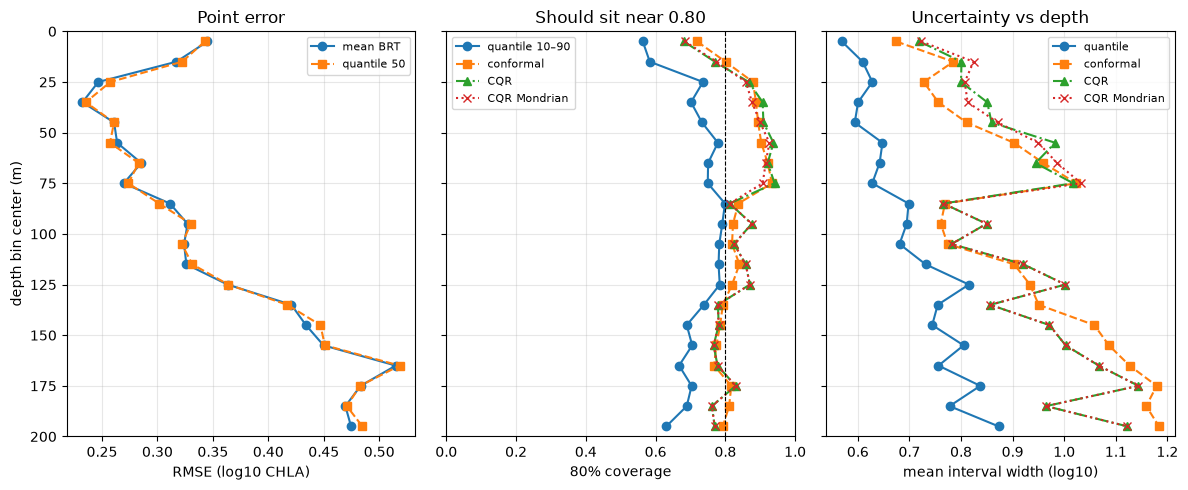

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
z = by_depth["z_center_m"]

axes[0].plot(by_depth["rmse_mean"], z, "o-", label="mean BRT")
axes[0].plot(by_depth["rmse_q50"], z, "s--", label="quantile 50")
axes[0].set_xlabel("RMSE (log10 CHLA)")
axes[0].set_title("Point error")
axes[0].legend(fontsize=8)

axes[1].plot(by_depth["quantile_coverage_80"], z, "o-", label="quantile 10–90")
axes[1].plot(by_depth["conformal_coverage_80"], z, "s--", label="conformal")
axes[1].plot(by_depth["cqr_coverage_80"], z, "^-.", label="CQR")
axes[1].plot(by_depth["mondrian_coverage_80"], z, "x:", label="CQR Mondrian")
axes[1].axvline(0.80, color="k", ls="--", lw=0.8)
axes[1].set_xlabel("80% coverage")
axes[1].set_xlim(0, 1)
axes[1].set_title("Should sit near 0.80")
axes[1].legend(fontsize=8)

axes[2].plot(by_depth["quantile_width_log"], z, "o-", label="quantile")
axes[2].plot(by_depth["conformal_width_log"], z, "s--", label="conformal")
axes[2].plot(by_depth["cqr_width_log"], z, "^-.", label="CQR")
axes[2].plot(by_depth["mondrian_width_log"], z, "x:", label="CQR Mondrian")
axes[2].set_xlabel("mean interval width (log10)")
axes[2].set_title("Uncertainty vs depth")
axes[2].legend(fontsize=8)

axes[0].set_ylabel("depth bin center (m)")
axes[0].set_ylim(200, 0)
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Coverage vs predicted CHLA


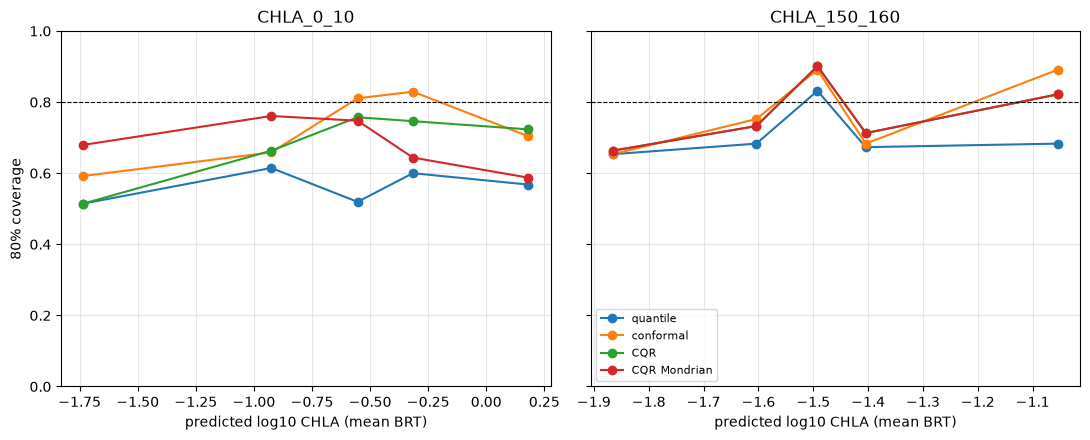

surface coverage by predicted-CHLA quintile


,method,pred_mid,n,coverage_80,width_log
0,quantile,-1.733506,206,0.514563,0.674228
1,quantile,-0.924889,205,0.614634,0.706088
2,quantile,-0.553511,206,0.519417,0.572686
3,quantile,-0.315650,205,0.600000,0.480554
4,quantile,0.181326,206,0.567961,0.411418
5,conformal,-1.733506,206,0.592233,0.674422
6,conformal,-0.924889,205,0.658537,0.674422
7,conformal,-0.553511,206,0.810680,0.674422
8,conformal,-0.315650,205,0.829268,0.674422
9,conformal,0.181326,206,0.703883,0.674422


In [11]:
def coverage_by_pred(y, pred, lo, hi, n_bins=5, min_n=15):
    y, pred = np.asarray(y), np.asarray(pred)
    lo, hi = np.asarray(lo), np.asarray(hi)
    edges = np.unique(np.quantile(pred, np.linspace(0, 1, n_bins + 1)))
    rows = []
    for i in range(len(edges) - 1):
        if i < len(edges) - 2:
            m = (pred >= edges[i]) & (pred < edges[i + 1])
        else:
            m = (pred >= edges[i]) & (pred <= edges[i + 1])
        if int(m.sum()) < min_n:
            continue
        cov, wid = coverage_and_width(y[m], lo[m], hi[m])
        rows.append({
            "pred_mid": 0.5 * (edges[i] + edges[i + 1]),
            "n": int(m.sum()),
            "coverage_80": cov,
            "width_log": wid,
        })
    return pd.DataFrame(rows)


methods = [
    ("quantile", "lo_q", "hi_q"),
    ("conformal", "lo_c", "hi_c"),
    ("CQR", "lo_cqr", "hi_cqr"),
    ("CQR Mondrian", "lo_m", "hi_m"),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, y_col in zip(axes, ("CHLA_0_10", "CHLA_150_160")):
    d = saved_diag[y_col]
    for name, lo_k, hi_k in methods:
        tab = coverage_by_pred(d["y"], d["pred"], d[lo_k], d[hi_k])
        ax.plot(tab["pred_mid"], tab["coverage_80"], "o-", label=name)
    ax.axhline(0.80, color="k", ls="--", lw=0.8)
    ax.set_ylim(0, 1)
    ax.set_xlabel("predicted log10 CHLA (mean BRT)")
    ax.set_title(y_col)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("80% coverage")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("surface coverage by predicted-CHLA quintile")
tabs = []
for name, lo_k, hi_k in methods:
    tab = coverage_by_pred(
        saved_diag["CHLA_0_10"]["y"], saved_diag["CHLA_0_10"]["pred"],
        saved_diag["CHLA_0_10"][lo_k], saved_diag["CHLA_0_10"][hi_k],
    )
    tab.insert(0, "method", name)
    tabs.append(tab)
pd.concat(tabs, ignore_index=True)

## Propagate PACE Rrs uncertainty (gain Monte Carlo)

CQR is **CHLA | Rrs**. Here we jitter the **spectrum** and see how much \(\log_{10}\mathrm{CHLA}\) moves.

Each test row gets one multiplicative gain on **all** `pace_Rrs_*` bands: \(Rrs \leftarrow Rrs \times (1+\delta)\), \(\delta \sim N(0, 0.05^2)\), then clip at 0. Nearby wavelengths stay correlated (a single gain, not 172 independent knobs). `solar_hour` and `type` are not perturbed. \(B=100\) draws; envelope is the 10–90% of the mean BRT.

This is a **sensitivity** test (training files have no `Rrs_unc`). CQR already includes typical matchup Rrs error — **do not add MC width to CQR**. If the MC envelope is much narrower than CQR, residual UQ dominates and CQR is still the interval to ship.


In [12]:
RRS_FEATS = [c for c in feats if c.startswith("pace_Rrs_")]
MC_SIGMA = 0.05
MC_B = 100


def mc_gain_predict(model, X, sigma=MC_SIGMA, n_draw=MC_B, seed=42):
    """Per-row gain on all PACE Rrs; returns 10% / 90% of mean-BRT log10 CHLA."""
    X = X.reset_index(drop=True)
    base = X[RRS_FEATS].to_numpy(dtype=float)
    n = len(X)
    rng = np.random.default_rng(seed)
    preds = np.empty((n_draw, n), dtype=float)
    Xp = X.copy()
    for b in range(n_draw):
        delta = rng.normal(0.0, sigma, size=n)
        pert = np.maximum(base * (1.0 + delta[:, None]), 0.0)
        Xp.loc[:, RRS_FEATS] = pert
        preds[b] = model.predict(Xp)
    lo, hi = np.quantile(preds, [0.10, 0.90], axis=0)
    return lo, hi


lo_mc_s, hi_mc_s = mc_gain_predict(mean_brt, X_test, seed=42)
cov_mc_s, wid_mc_s = coverage_and_width(y_test, lo_mc_s, hi_mc_s)

mc_surface = pd.DataFrame([
    {"layer": "CQR (CHLA | Rrs)", "coverage_80": cov_cqr, "mean_width_log": wid_cqr},
    {"layer": "Rrs 5% gain MC (through mean BRT)", "coverage_80": cov_mc_s, "mean_width_log": wid_mc_s},
])
print(
    f"surface MC 10–90% width={wid_mc_s:.3f}  vs CQR width={wid_cqr:.3f}  "
    f"(MC/CQR = {wid_mc_s / wid_cqr:.2f})"
)
print("MC coverage of in situ is expected to be << 0.80 (input UQ only).")
mc_surface

surface MC 10–90% width=0.138  vs CQR width=0.719  (MC/CQR = 0.19)
MC coverage of in situ is expected to be << 0.80 (input UQ only).


,layer,coverage_80,mean_width_log
0,CQR (CHLA | Rrs),0.680934,0.719223
1,Rrs 5% gain MC (through mean BRT),0.165370,0.138206


CHLA_0_10         MC width=0.138  MC cov=0.17
CHLA_10_20        MC width=0.158  MC cov=0.18
CHLA_20_30        MC width=0.139  MC cov=0.19
CHLA_30_40        MC width=0.136  MC cov=0.21
CHLA_40_50        MC width=0.130  MC cov=0.21
CHLA_50_60        MC width=0.114  MC cov=0.17
CHLA_60_70        MC width=0.128  MC cov=0.18
CHLA_70_80        MC width=0.110  MC cov=0.17
CHLA_80_90        MC width=0.098  MC cov=0.13
CHLA_90_100       MC width=0.098  MC cov=0.16
CHLA_100_110      MC width=0.107  MC cov=0.20
CHLA_110_120      MC width=0.106  MC cov=0.17
CHLA_120_130      MC width=0.114  MC cov=0.17
CHLA_130_140      MC width=0.142  MC cov=0.20
CHLA_140_150      MC width=0.139  MC cov=0.20
CHLA_150_160      MC width=0.109  MC cov=0.16
CHLA_160_170      MC width=0.137  MC cov=0.22
CHLA_170_180      MC width=0.108  MC cov=0.11
CHLA_180_190      MC width=0.109  MC cov=0.13
CHLA_190_200      MC width=0.143  MC cov=0.14


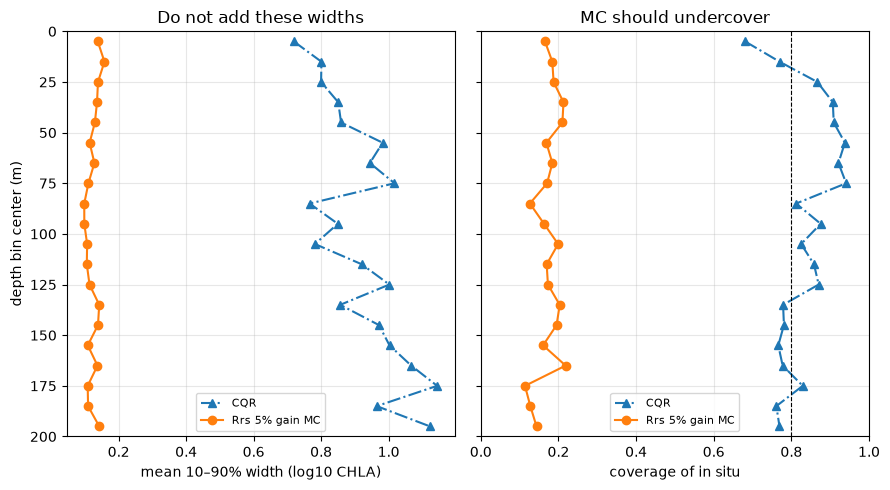

,bin,z_center_m,cqr_width_log,mc_width_log,cqr_coverage_80,mc_coverage_80
0,CHLA_0_10,5.0,0.719223,0.138206,0.680934,0.165370
1,CHLA_10_20,15.0,0.800870,0.157895,0.769737,0.184211
2,CHLA_20_30,25.0,0.799924,0.138760,0.866935,0.187500
3,CHLA_30_40,35.0,0.850706,0.135897,0.906844,0.212928
4,CHLA_40_50,45.0,0.859149,0.129552,0.909091,0.210227
5,CHLA_50_60,55.0,0.982392,0.114072,0.937864,0.168932
6,CHLA_60_70,65.0,0.944475,0.128149,0.921305,0.184261
7,CHLA_70_80,75.0,1.017447,0.110381,0.941176,0.170778
8,CHLA_80_90,85.0,0.765892,0.098089,0.812261,0.126437
9,CHLA_90_100,95.0,0.849376,0.098233,0.875479,0.162835


In [13]:
mc_rows = []
for y_col in mean_models:
    _, Xte, yte = bin_xy(dataset, test_idx, y_col)
    lo_mc, hi_mc = mc_gain_predict(mean_models[y_col], Xte, seed=42)
    cov_mc, wid_mc = coverage_and_width(yte, lo_mc, hi_mc)
    z0, z1 = parse_depth_bin(y_col)
    mc_rows.append({
        "bin": y_col,
        "z_center_m": 0.5 * (z0 + z1),
        "n_test": len(yte),
        "mc_coverage_80": cov_mc,
        "mc_width_log": wid_mc,
    })
    print(f"{y_col:16}  MC width={wid_mc:.3f}  MC cov={cov_mc:.2f}")

mc_by_depth = pd.DataFrame(mc_rows)
by_depth_mc = by_depth.merge(mc_by_depth.drop(columns=["z_center_m", "n_test"]), on="bin")

fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)
z = by_depth_mc["z_center_m"]
axes[0].plot(by_depth_mc["cqr_width_log"], z, "^-.", label="CQR")
axes[0].plot(by_depth_mc["mc_width_log"], z, "o-", label="Rrs 5% gain MC")
axes[0].set_xlabel("mean 10–90% width (log10 CHLA)")
axes[0].set_title("Do not add these widths")
axes[0].legend(fontsize=8)

axes[1].plot(by_depth_mc["cqr_coverage_80"], z, "^-.", label="CQR")
axes[1].plot(by_depth_mc["mc_coverage_80"], z, "o-", label="Rrs 5% gain MC")
axes[1].axvline(0.80, color="k", ls="--", lw=0.8)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("coverage of in situ")
axes[1].set_title("MC should undercover")
axes[1].legend(fontsize=8)

axes[0].set_ylabel("depth bin center (m)")
axes[0].set_ylim(200, 0)
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
by_depth_mc[["bin", "z_center_m", "cqr_width_log", "mc_width_log", "cqr_coverage_80", "mc_coverage_80"]]

### Example test profiles

Same gain \(\delta\) at every depth for a given draw (one perturbed spectrum → one profile). Shading is the MC 10–90%; dashed is CQR. In situ is black.

Re-run the all-depth cell first so `mean_models` and `cqr_pack` exist.


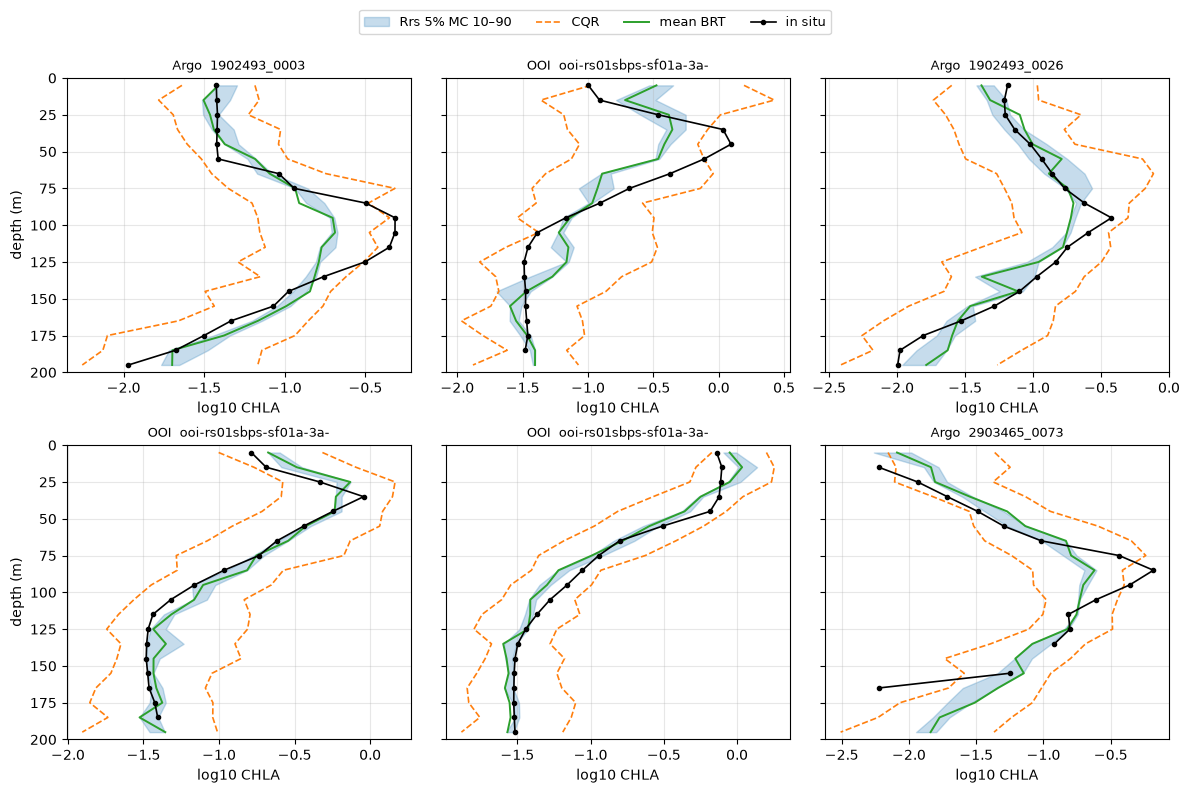

In [14]:
def profile_from_row(row, n_draw=MC_B, sigma=MC_SIGMA, seed=0):
    X0 = pd.DataFrame([{c: row[c] for c in feats}])
    base = X0[RRS_FEATS].to_numpy(dtype=float)
    rng = np.random.default_rng(seed)
    deltas = rng.normal(0.0, sigma, size=n_draw)
    z, y_obs, y_mean, lo_mc, hi_mc, lo_cq, hi_cq = [], [], [], [], [], [], []
    Xp = X0.copy()
    for col in chl_cols:
        if col not in mean_models:
            continue
        a, b = parse_depth_bin(col)
        z.append(0.5 * (a + b))
        val = row[col]
        y_obs.append(np.log10(val) if pd.notna(val) and val > 0 else np.nan)
        y_mean.append(float(mean_models[col].predict(X0)[0]))
        pack = cqr_pack[col]
        qlo, qhi = q_interval(pack["q10"], pack["q90"], X0)
        lo_cq.append(float(qlo[0] - pack["e_pad"]))
        hi_cq.append(float(qhi[0] + pack["e_pad"]))
        draws = np.empty(n_draw)
        for b_i, d in enumerate(deltas):
            pert = np.maximum(base * (1.0 + d), 0.0)
            Xp.loc[:, RRS_FEATS] = pert
            draws[b_i] = mean_models[col].predict(Xp)[0]
        lo_mc.append(float(np.quantile(draws, 0.10)))
        hi_mc.append(float(np.quantile(draws, 0.90)))
    return {
        "z": np.asarray(z),
        "obs": np.asarray(y_obs),
        "mean": np.asarray(y_mean),
        "lo_mc": np.asarray(lo_mc),
        "hi_mc": np.asarray(hi_mc),
        "lo_cqr": np.asarray(lo_cq),
        "hi_cqr": np.asarray(hi_cq),
    }


test_df = dataset.iloc[test_idx]
n_bins = test_df[chl_cols].notna().sum(axis=1)
eligible = test_df.loc[n_bins >= 8]
if len(eligible) < 6:
    eligible = test_df
prof_rows = eligible.sample(n=6, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharey=True)
axes = np.asarray(axes).ravel()
for i, (_, row) in enumerate(prof_rows.iterrows()):
    ax = axes[i]
    p = profile_from_row(row, seed=42 + i)
    src = "Argo" if row["type"] == 0 else "OOI"
    ax.fill_betweenx(p["z"], p["lo_mc"], p["hi_mc"], color="C0", alpha=0.25, label="Rrs 5% MC 10–90")
    ax.plot(p["lo_cqr"], p["z"], color="C1", ls="--", lw=1.2, label="CQR")
    ax.plot(p["hi_cqr"], p["z"], color="C1", ls="--", lw=1.2)
    ax.plot(p["mean"], p["z"], color="C2", lw=1.4, label="mean BRT")
    ax.plot(p["obs"], p["z"], color="k", marker="o", ms=3, lw=1.2, label="in situ")
    ax.set_ylim(200, 0)
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{src}  {str(row['profile_id'])[:22]}", fontsize=9)
    ax.set_xlabel("log10 CHLA")
axes[0].set_ylabel("depth (m)")
axes[3].set_ylabel("depth (m)")
handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout()
fig.subplots_adjust(top=0.90)
fig.legend(handles, labels, loc="center", ncol=4, bbox_to_anchor=(0.5, 0.97),
           frameon=True, fontsize=9)
plt.show()

## CQR on the OLCI–PACE overlap

Same biofouling table, restricted to `profile_id`s with **all 11 OLCI bands** finite (the `olci_l3_brt_compare.ipynb` sample). Drop duplicate OOI ids so the join is one row per profile.

**New** grouped split on this overlap (not the full-table groups — many floats have no OLCI pixel). Fit **CQR only** twice on those ids:

1. **PACE-full** — ~172 `pace_Rrs_*`
2. **OLCI-11** — the 11 `olci_Rrs_*` bands

This is UQ on the sensor-compare sample, not a claim that OLCI CQR matches the full-table numbers above.


In [15]:
if not OLCI_FILE.is_file():
    raise FileNotFoundError(OLCI_FILE)

olci = pd.read_parquet(OLCI_FILE)
olci_ok = olci.loc[olci[OLCI_COLS].notna().all(axis=1), ["profile_id"] + OLCI_COLS]
overlap = (
    dataset.drop_duplicates("profile_id")
    .merge(olci_ok, on="profile_id", how="inner")
    .reset_index(drop=True)
)
print(
    "OLCI overlap rows:", len(overlap),
    "Argo:", int((overlap["type"] == 0).sum()),
    "OOI:", int((overlap["type"] == 1).sum()),
    "groups:", overlap["group_id"].nunique(),
)

ov_train, ov_test = split_by_group(overlap, test_size=0.2, random_state=42)
ov_fit_rel, ov_cal_rel = split_by_group(
    overlap.iloc[ov_train].reset_index(drop=True), test_size=0.2, random_state=42,
)
ov_fit = ov_train[ov_fit_rel]
ov_cal = ov_train[ov_cal_rel]
assert set(overlap.iloc[ov_train]["group_id"]).isdisjoint(set(overlap.iloc[ov_test]["group_id"]))
print(
    f"overlap train={len(ov_train)}  fit={len(ov_fit)}  calib={len(ov_cal)}  test={len(ov_test)}  "
    f"({overlap.iloc[ov_test]['group_id'].nunique()} test groups)"
)

OV_MODELS = {
    "PACE-full": [c for c in overlap.columns if c.startswith("pace_Rrs_") and c[-1].isdigit()]
    + [c for c in EXTRA if c in overlap.columns],
    "OLCI-11": OLCI_COLS + [c for c in EXTRA if c in overlap.columns],
}
print({k: len(v) for k, v in OV_MODELS.items()})


def cqr_on_bin(df, y_col, feat_cols, train_idx, fit_idx, cal_idx, test_idx):
    _, Xtr, ytr = bin_xy(df, train_idx, y_col, feat_cols)
    _, Xfi, yfi = bin_xy(df, fit_idx, y_col, feat_cols)
    _, Xca, yca = bin_xy(df, cal_idx, y_col, feat_cols)
    _, Xte, yte = bin_xy(df, test_idx, y_col, feat_cols)
    if min(len(yte), len(ytr), len(yca), len(yfi)) < 20:
        return None
    q10_c = fit_quantile(0.10, Xfi, yfi)
    q90_c = fit_quantile(0.90, Xfi, yfi)
    lo_ca, hi_ca = q_interval(q10_c, q90_c, Xca)
    e_pad = conformal_cutoff(cqr_scores(yca, lo_ca, hi_ca))
    m50 = fit_quantile(0.50, Xtr, ytr)
    yhat = m50.predict(Xte)
    lo0, hi0 = q_interval(q10_c, q90_c, Xte)
    lo, hi = lo0 - e_pad, hi0 + e_pad
    cov, wid = coverage_and_width(yte, lo, hi)
    rmse = float(np.sqrt(mean_squared_error(yte, yhat)))
    return {
        "n_train": len(ytr),
        "n_test": len(yte),
        "rmse_log": rmse,
        "coverage_80": cov,
        "width_log": wid,
        "pad_log": e_pad,
    }


print("\nsurface CQR on overlap")
ov_surf = []
for name, fcols in OV_MODELS.items():
    rec = cqr_on_bin(overlap, "CHLA_0_10", fcols, ov_train, ov_fit, ov_cal, ov_test)
    if rec is None:
        print("skip surface", name)
        continue
    rec = {"features": name, **rec}
    ov_surf.append(rec)
    print(
        f"{name:10}  n_test={rec['n_test']}  RMSE={rec['rmse_log']:.3f}  "
        f"cov={rec['coverage_80']:.3f}  width={rec['width_log']:.3f}  pad={rec['pad_log']:.3f}"
    )
pd.DataFrame(ov_surf)


OLCI overlap rows: 2369 Argo: 1467 OOI: 902 groups: 358
overlap train=1779  fit=1378  calib=401  test=590  (72 test groups)
{'PACE-full': 174, 'OLCI-11': 13}

surface CQR on overlap
PACE-full   n_test=438  RMSE=0.295  cov=0.799  width=0.819  pad=0.008
OLCI-11     n_test=438  RMSE=0.312  cov=0.817  width=0.739  pad=0.034


,features,n_train,n_test,rmse_log,coverage_80,width_log,pad_log
0,PACE-full,1108,438,0.294601,0.799087,0.818958,0.008480
1,OLCI-11,1108,438,0.312104,0.817352,0.739080,0.034363


CHLA_0_10        PACE-full   n_test= 438  cov=0.80  width=0.82  RMSE=0.295
CHLA_0_10        OLCI-11     n_test= 438  cov=0.82  width=0.74  RMSE=0.312
CHLA_10_20       PACE-full   n_test= 286  cov=0.82  width=0.87  RMSE=0.304
CHLA_10_20       OLCI-11     n_test= 286  cov=0.77  width=0.69  RMSE=0.293
CHLA_20_30       PACE-full   n_test= 296  cov=0.85  width=0.82  RMSE=0.300
CHLA_20_30       OLCI-11     n_test= 296  cov=0.84  width=0.76  RMSE=0.284
CHLA_30_40       PACE-full   n_test= 334  cov=0.87  width=0.85  RMSE=0.307
CHLA_30_40       OLCI-11     n_test= 334  cov=0.84  width=0.75  RMSE=0.307
CHLA_40_50       PACE-full   n_test= 316  cov=0.86  width=0.82  RMSE=0.283
CHLA_40_50       OLCI-11     n_test= 316  cov=0.80  width=0.71  RMSE=0.295
CHLA_50_60       PACE-full   n_test= 314  cov=0.77  width=0.76  RMSE=0.322
CHLA_50_60       OLCI-11     n_test= 314  cov=0.75  width=0.66  RMSE=0.321
CHLA_60_70       PACE-full   n_test= 311  cov=0.72  width=0.72  RMSE=0.348
CHLA_60_70       OLCI-11 

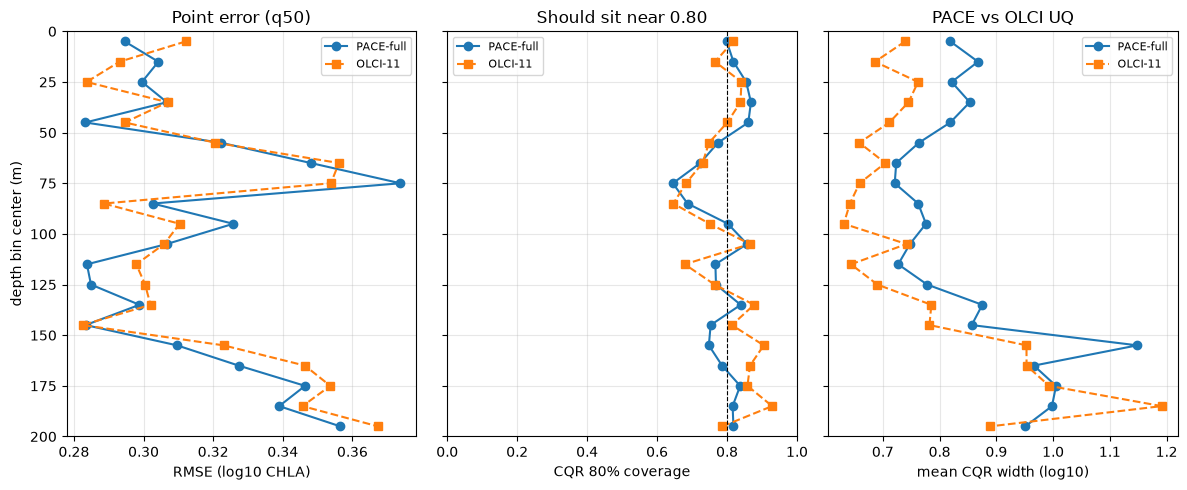

,bin,z_center_m,features,n_train,n_test,rmse_log,coverage_80,width_log,pad_log
0,CHLA_0_10,5.0,PACE-full,1108,438,0.294601,0.799087,0.818958,0.008480
1,CHLA_0_10,5.0,OLCI-11,1108,438,0.312104,0.817352,0.739080,0.034363
2,CHLA_10_20,15.0,PACE-full,745,286,0.304254,0.818182,0.867689,0.131647
3,CHLA_10_20,15.0,OLCI-11,745,286,0.293095,0.765734,0.686173,0.002801
4,CHLA_20_30,25.0,PACE-full,943,296,0.299541,0.854730,0.821215,0.126314
5,CHLA_20_30,25.0,OLCI-11,943,296,0.283631,0.841216,0.762053,0.086626
6,CHLA_30_40,35.0,PACE-full,981,334,0.306709,0.868263,0.853152,0.152337
7,CHLA_30_40,35.0,OLCI-11,981,334,0.306892,0.838323,0.745166,0.113042
8,CHLA_40_50,45.0,PACE-full,998,316,0.283265,0.860759,0.818704,0.143132
9,CHLA_40_50,45.0,OLCI-11,998,316,0.294633,0.800633,0.711398,0.105894


In [16]:
ov_depth = []
for y_col in chl_cols:
    z0, z1 = parse_depth_bin(y_col)
    zc = 0.5 * (z0 + z1)
    for name, fcols in OV_MODELS.items():
        rec = cqr_on_bin(overlap, y_col, fcols, ov_train, ov_fit, ov_cal, ov_test)
        if rec is None:
            print(f"skip {y_col} {name}")
            continue
        ov_depth.append({"bin": y_col, "z_center_m": zc, "features": name, **rec})
        print(
            f"{y_col:16} {name:10}  n_test={rec['n_test']:4d}  "
            f"cov={rec['coverage_80']:.2f}  width={rec['width_log']:.2f}  RMSE={rec['rmse_log']:.3f}"
        )

ov_by_depth = pd.DataFrame(ov_depth)
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
for name, style in [("PACE-full", "o-"), ("OLCI-11", "s--")]:
    d = ov_by_depth.loc[ov_by_depth["features"] == name]
    axes[0].plot(d["rmse_log"], d["z_center_m"], style, label=name)
    axes[1].plot(d["coverage_80"], d["z_center_m"], style, label=name)
    axes[2].plot(d["width_log"], d["z_center_m"], style, label=name)
axes[0].set_xlabel("RMSE (log10 CHLA)")
axes[0].set_title("Point error (q50)")
axes[1].axvline(0.80, color="k", ls="--", lw=0.8)
axes[1].set_xlabel("CQR 80% coverage")
axes[1].set_xlim(0, 1)
axes[1].set_title("Should sit near 0.80")
axes[2].set_xlabel("mean CQR width (log10)")
axes[2].set_title("PACE vs OLCI UQ")
axes[0].set_ylabel("depth bin center (m)")
axes[0].set_ylim(200, 0)
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
ov_by_depth
